# Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torch torchvision pandas numpy matplotlib seaborn scikit-learn pillow tqdm

# Imports

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score
from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


# Path Setup

In [ ]:
BASE_DIR = "/content/drive/MyDrive/ML_Lab"

TRAIN_CSV = f"{BASE_DIR}/dataset/splits/train.csv"
VAL_CSV = f"{BASE_DIR}/dataset/splits/val.csv"

IMAGE_DIR = f"{BASE_DIR}/dataset"

MODEL_SAVE_PATH = f"{BASE_DIR}/models/resnet50_best.pth"

PLOT_DIR = f"{BASE_DIR}/outputs/plots"

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/models", exist_ok=True)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/ML_Lab/dataset/metadata.csv")

df.head()

,filename,fish_type,background,lighting,image_path
0,chikka_tiles_background_flash_light_01,chikka,above_newspaper,flash_light,raw\chikka\above_newspaper\flash_light\chikka_...
1,chikka_tiles_background_flash_light_02,chikka,above_newspaper,flash_light,raw\chikka\above_newspaper\flash_light\chikka_...
2,chikka_tiles_background_flash_light_03,chikka,above_newspaper,flash_light,raw\chikka\above_newspaper\flash_light\chikka_...
3,chikka_tiles_background_flash_light_04,chikka,above_newspaper,flash_light,raw\chikka\above_newspaper\flash_light\chikka_...
4,chikka_tiles_background_flash_light_05,chikka,above_newspaper,flash_light,raw\chikka\above_newspaper\flash_light\chikka_...


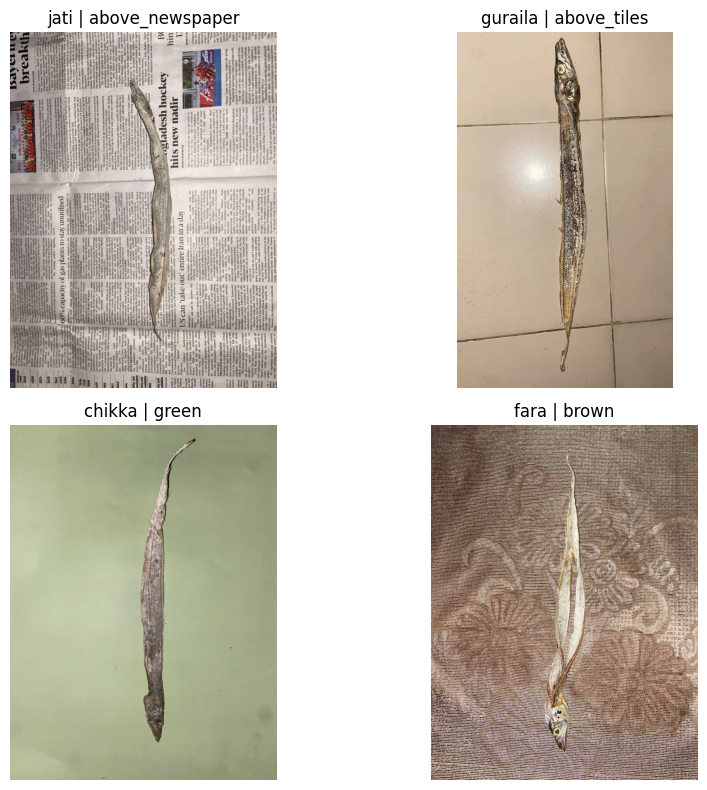

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

BASE_DIR = "/content/drive/MyDrive/ML_Lab/dataset"

mapping = {
    "jati": "above_newspaper",
    "guraila": "above_tiles",
    "chikka": "green",
    "fara": "brown"
}

plt.figure(figsize=(10, 8))

count = 1

for fish, bg in mapping.items():

    filtered = df[
        (df["fish_type"] == fish) &
        (df["background"] == bg)
    ]

    if len(filtered) == 0:
        print(f"Skipping {fish} | {bg} (no data found)")
        continue

    row = filtered.iloc[0]

    img_path = os.path.join(
        BASE_DIR,
        row["image_path"].replace("\\", "/")
    )

    if not os.path.exists(img_path):
        print(f"Missing file: {img_path}")
        continue

    img = Image.open(img_path)

    plt.subplot(2, 2, count)
    plt.imshow(img)
    plt.title(f"{fish} | {bg}")
    plt.axis("off")

    count += 1

plt.tight_layout()
plt.show()

# Data Augmentation

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(25),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        shear=10
    ),

    transforms.GaussianBlur(kernel_size=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset Class

In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class FishDataset(Dataset):

    def __init__(self, csv_file, root_dir, transform=None):

        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(self.df["fish_type"].unique())

        self.class_to_idx = {
            cls: idx for idx, cls in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        relative_path = row["image_path"].replace("\\", "/")

        image_path = os.path.join(
            self.root_dir,
            relative_path
        )

        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Missing file: {image_path}")

        image = Image.open(image_path).convert("RGB")

        label = self.class_to_idx[row["fish_type"]]

        if self.transform:
            image = self.transform(image)

        return image, label

# Dataloader

In [ ]:
train_dataset = FishDataset(
    TRAIN_CSV,
    IMAGE_DIR,
    transform=train_transform
)

val_dataset = FishDataset(
    VAL_CSV,
    IMAGE_DIR,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# Load ResNet50

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 4)
)

model = model.to(device)

# Loss + Optimizer + Scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

# Training

In [ ]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

EPOCHS = 10

# Training Loop

In [ ]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ================= TRAIN =================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ================= VALIDATION =================

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)

    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")

    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    # SAVE BEST MODEL

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(model.state_dict(), MODEL_SAVE_PATH)

        print("Best Model Saved!")


Epoch 1/10


100%|██████████| 8/8 [01:07<00:00,  8.38s/it]


Train Loss: 1.3100
Train Acc : 0.4205
Val Loss  : 1.1280
Val Acc   : 0.7478
Best Model Saved!

Epoch 2/10


100%|██████████| 8/8 [00:51<00:00,  6.44s/it]


Train Loss: 0.7861
Train Acc : 0.7712
Val Loss  : 0.4389
Val Acc   : 0.8522
Best Model Saved!

Epoch 3/10


...

Train Loss: 0.0583
Train Acc : 0.9851
Val Loss  : 0.0774
Val Acc   : 0.9783

Epoch 9/10


100%|██████████| 8/8 [00:50<00:00,  6.28s/it]


Train Loss: 0.0633
Train Acc : 0.9842
Val Loss  : 0.0189
Val Acc   : 0.9957

Epoch 10/10


100%|██████████| 8/8 [00:53<00:00,  6.67s/it]

Train Loss: 0.0523
Train Acc : 0.9842
Val Loss  : 0.0177
Val Acc   : 0.9870


# Accuracy Curve

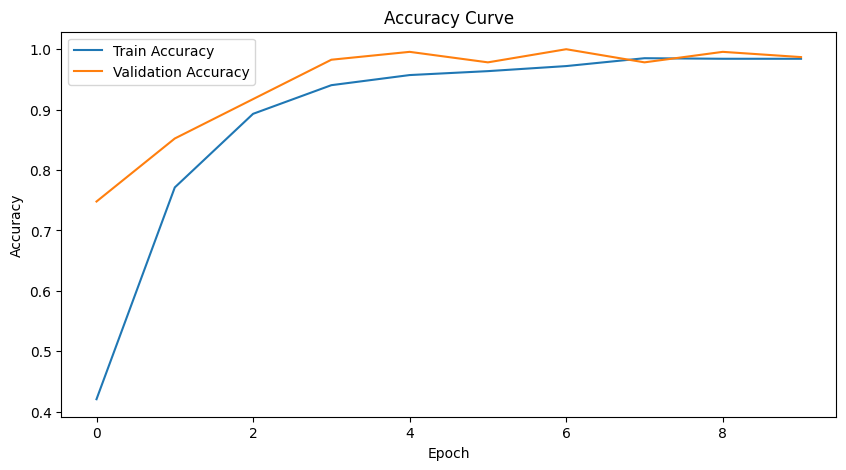

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.savefig(f"{PLOT_DIR}/accuracy_curve.png")

plt.show()

# Loss Curve

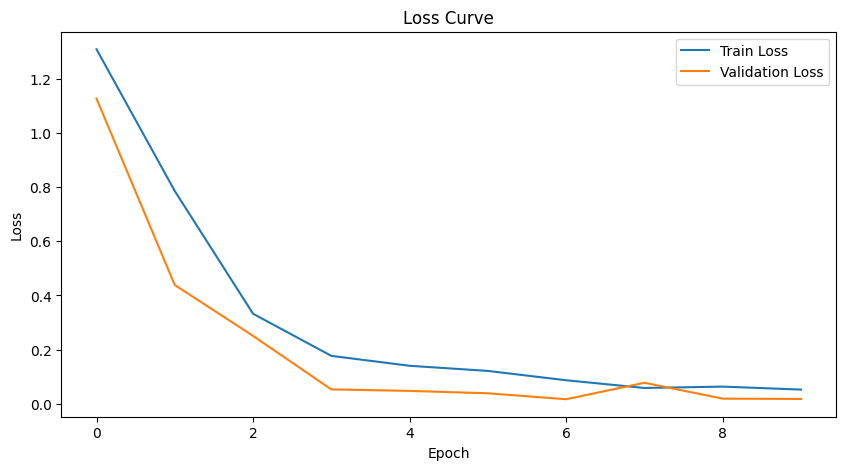

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.savefig(f"{PLOT_DIR}/loss_curve.png")

plt.show()

# Evaluation

# Imports

In [ ]:
import os
import numpy as np
import pandas as pd

import torch

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

# Paths

In [ ]:
BASE_DIR = "/content/drive/MyDrive/ML_Lab"

TEST_CSV = f"{BASE_DIR}/dataset/splits/test.csv"

IMAGE_DIR = f"{BASE_DIR}/dataset"

MODEL_PATH = f"{BASE_DIR}/models/resnet50_best.pth"

RESULT_DIR = f"{BASE_DIR}/outputs/results"

PLOT_DIR = f"{BASE_DIR}/outputs/plots"

os.makedirs(RESULT_DIR, exist_ok=True)

# Transform

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset

In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class FishDataset(Dataset):

    def __init__(self, csv_file, root_dir, transform=None):

        self.df = pd.read_csv(csv_file)

        self.root_dir = root_dir

        self.transform = transform

        self.classes = sorted(self.df["fish_type"].unique())

        self.class_to_idx = {
            cls_name: idx
            for idx, cls_name in enumerate(self.classes)
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        relative_path = row["image_path"].replace("\\", "/")

        image_path = os.path.join(
            self.root_dir,
            relative_path
        )

        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Missing file: {image_path}")

        image = Image.open(image_path).convert("RGB")

        label = self.class_to_idx[row["fish_type"]]

        if self.transform:
            image = self.transform(image)

        return image, label

# Test Loader

In [ ]:
test_dataset = FishDataset(
    TEST_CSV,
    IMAGE_DIR,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Load Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)

num_features = model.fc.in_features

model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(num_features, 4)
)

model.load_state_dict(torch.load(MODEL_PATH))

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Prediction

In [ ]:
all_labels = []
all_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())

# Accuracy

In [ ]:
acc = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", acc)

Test Accuracy: 0.987012987012987


# Classification Report

In [ ]:
class_names = test_dataset.classes

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

with open(f"{RESULT_DIR}/classification_report.txt", "w") as f:
    f.write(report)

              precision    recall  f1-score   support

      chikka       1.00      0.95      0.97        57
        fara       0.95      1.00      0.97        58
     guraila       1.00      1.00      1.00        58
        jati       1.00      1.00      1.00        58

    accuracy                           0.99       231
   macro avg       0.99      0.99      0.99       231
weighted avg       0.99      0.99      0.99       231



# Confusion Matrix

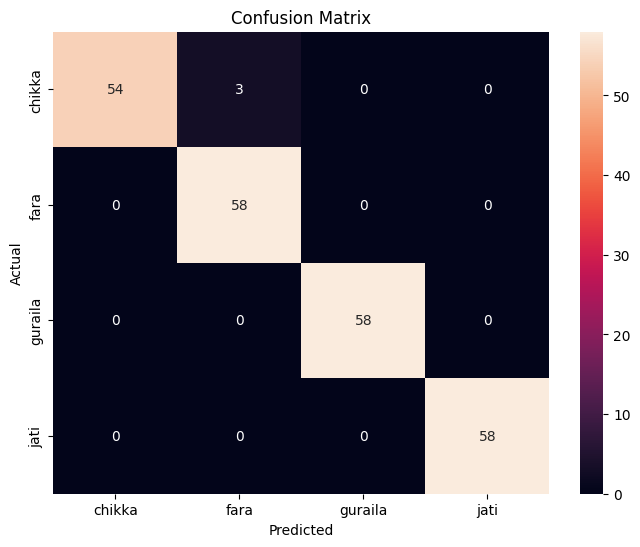

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(f"{PLOT_DIR}/confusion_matrix.png")

plt.show()

# background_analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

metadata = pd.read_csv("/content/drive/MyDrive/ML_Lab/dataset/metadata.csv")

# Background Accuracy

In [ ]:
background_counts = metadata["background"].value_counts()

print(background_counts)

background
above_newspaper    192
above_tiles        192
black              192
brown              192
green              192
poli               192
table_maat         192
white              192
Name: count, dtype: int64


Test Data loaded:
                                    filename fish_type   background  \
0   chikka_brown_background_natural_light_04    chikka        brown   
1  jati_table_maat_background_flash_light_03      jati   table_maat   
2  chikka_table_maat_background_low_light_09    chikka   table_maat   
3    fara_brown_background_natural_light_002      fara        brown   
4       jati_tiles_background_flash_light_01      jati  above_tiles   

        lighting                                         image_path  
0  natural_light  raw\chikka\brown\natural_light\chikka_brown_ba...  
1    flash_light  raw\jati\table_maat\flash_light\jati_table_maa...  
2      low_light  raw\chikka\table_maat\low_light\chikka_table_m...  
3  natural_light  raw\fara\brown\natural_light\fara_brown_backgr...  
4    flash_light  raw\jati\above_tiles\flash_light\jati_tiles_ba...  

Columns: Index(['filename', 'fish_type', 'background', 'lighting', 'image_path'], dtype='object')

Background-wise Accuracy:
backgroun

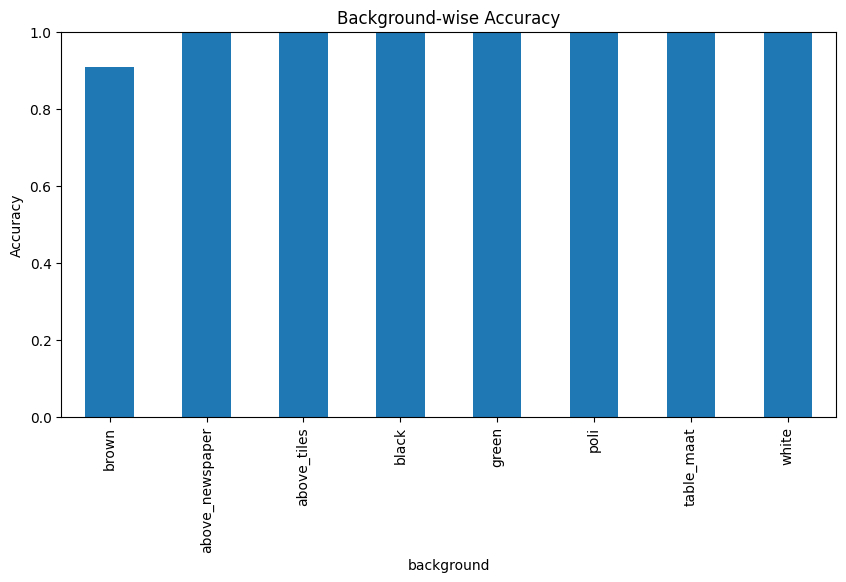

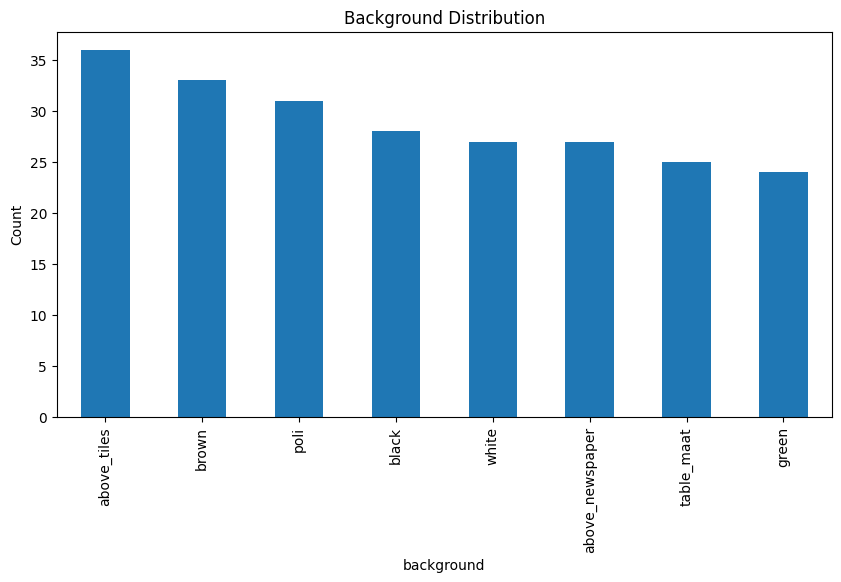

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test_df = pd.read_csv("/content/drive/MyDrive/ML_Lab/dataset/splits/test.csv")

print("Test Data loaded:")
print(test_df.head())
print("\nColumns:", test_df.columns)

test_df["true"] = all_labels
test_df["pred"] = all_preds

test_df["correct"] = test_df["true"] == test_df["pred"]

bg_accuracy = test_df.groupby("background")["correct"].mean()

print("\nBackground-wise Accuracy:")
print(bg_accuracy)

bg_count = test_df["background"].value_counts()

print("\nBackground-wise Image Count:")
print(bg_count)

bg_report = pd.DataFrame({
    "image_count": bg_count,
    "accuracy": bg_accuracy
})

print("\nFinal Report:")
print(bg_report)

plt.figure(figsize=(10,5))
bg_accuracy.sort_values().plot(kind="bar")
plt.title("Background-wise Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(10,5))
bg_count.plot(kind="bar")
plt.title("Background Distribution")
plt.ylabel("Count")
plt.show()

# Lighting Distribution

In [ ]:
lighting_counts = metadata["lighting"].value_counts()

print(lighting_counts)

lighting
flash_light      384
low_light        384
natural_light    384
proper_light     384
Name: count, dtype: int64



Lighting-wise Accuracy:
lighting
flash_light      1.000000
low_light        0.952381
natural_light    1.000000
proper_light     1.000000
Name: correct, dtype: float64

Lighting-wise Image Count:
lighting
low_light        63
flash_light      57
natural_light    56
proper_light     55
Name: count, dtype: int64

Lighting Report:
               image_count  accuracy
lighting                            
flash_light             57  1.000000
low_light               63  0.952381
natural_light           56  1.000000
proper_light            55  1.000000


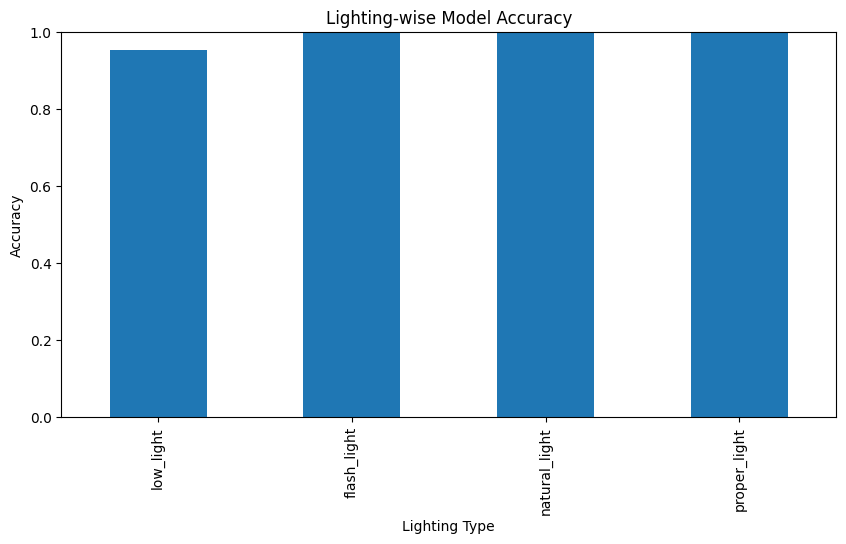

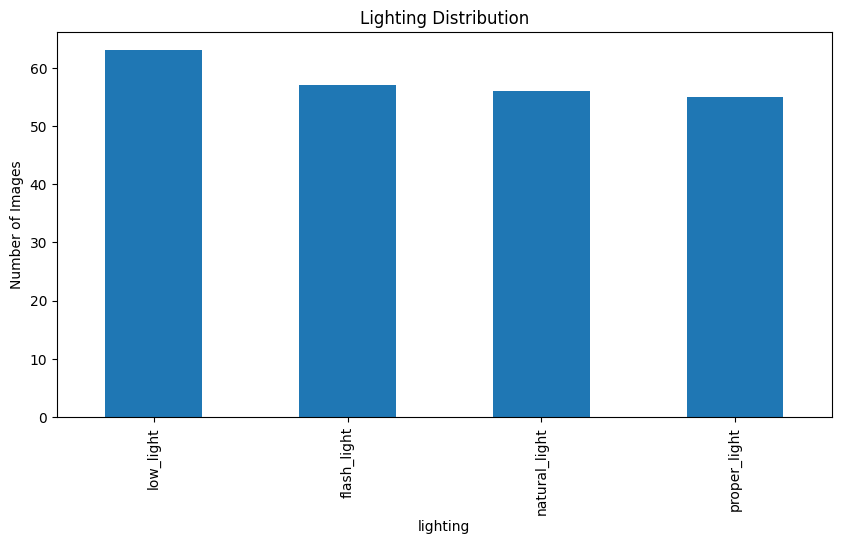

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

test_df = pd.read_csv("/content/drive/MyDrive/ML_Lab/dataset/splits/test.csv")

test_df["true"] = all_labels
test_df["pred"] = all_preds

test_df["correct"] = test_df["true"] == test_df["pred"]

lighting_accuracy = test_df.groupby("lighting")["correct"].mean()

print("\nLighting-wise Accuracy:")
print(lighting_accuracy)

lighting_count = test_df["lighting"].value_counts()

print("\nLighting-wise Image Count:")
print(lighting_count)

lighting_report = pd.DataFrame({
    "image_count": lighting_count,
    "accuracy": lighting_accuracy
})

print("\nLighting Report:")
print(lighting_report)

plt.figure(figsize=(10,5))

lighting_accuracy.sort_values().plot(kind="bar")

plt.title("Lighting-wise Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Lighting Type")
plt.ylim(0, 1)

plt.show()

plt.figure(figsize=(10,5))

lighting_count.plot(kind="bar")

plt.title("Lighting Distribution")
plt.ylabel("Number of Images")

plt.show()

# PREDICTION

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)

num_features = model.fc.in_features

model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(num_features, 4)
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/ML_Lab/dataset/splits/train.csv")

classes = sorted(train_df["fish_type"].unique())

class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

In [ ]:
import json

with open("/content/drive/MyDrive/ML_Lab/dataset/fish_info.json", "r") as f:
    fish_info = json.load(f)

In [ ]:
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
def get_fish_details(pred_class):

    for item in fish_info:
        if pred_class.lower() in item["id"].lower():
            return item

    return None

In [ ]:
def predict_image(img_path):

    image = Image.open(img_path).convert("RGB")

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, pred = torch.max(outputs, 1)

    class_name = idx_to_class[pred.item()]

    print("Prediction:", class_name)

    details = get_fish_details(class_name)

    if details:
        print_fish_details(details)
    else:
        print("No info found")



In [ ]:
def print_fish_details(details):

    print("\n📌 Fish Information")
    print("-" * 40)

    print(f"🆔 ID: {details.get('id', 'N/A')}")
    print(f"🐟 Bangla Name: {details.get('bangla_name', 'N/A')}")
    print(f"🌍 English Name: {details.get('english_name', 'N/A')}")
    print(f"📂 Category: {details.get('category', 'N/A')}")
    print(f"🔬 Scientific Name: {details.get('scientific_name', 'N/A')}")
    print(f"🏷️ Family: {details.get('family', 'N/A')}")
    print(f"🌊 Habitat: {details.get('habitat', 'N/A')}")
    print(f"📍 Origin: {details.get('origin', 'N/A')}")

    print(f"🍽️ Popular Dish: {', '.join(details.get('popular_dish', []))}")

    print("-" * 40)

Image: WhatsApp Image 2026-05-19 at 11.31.48 PM.jpeg


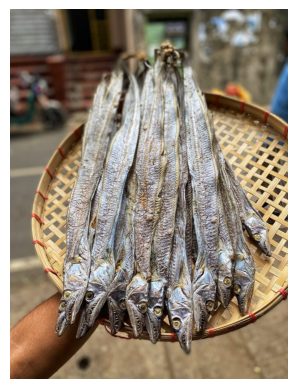

Prediction: fara

📌 Fish Information
----------------------------------------
🆔 ID: fara_churi
🐟 Bangla Name: ফারা ছুরি
🌍 English Name: Fara Churi
📂 Category: Ribbon Fish
🔬 Scientific Name: Trichiurus gangeticus
🏷️ Family: Trichiuridae
🌊 Habitat: Marine
📍 Origin: Bay of Bengal
🍽️ Popular Dish: Fried Ribbon Fish, Shutki Bhorta
----------------------------------------


In [ ]:
import os

test_folder = "/content/drive/MyDrive/ML_Lab/sample_image_for_prediction"

for img_name in os.listdir(test_folder):

    img_path = os.path.join(test_folder, img_name)

    if not img_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        continue

    print("Image:", img_name)

    predict_image(img_path)